In [ ]:
# Clone Project
!git clone https://github.com/dpduy123/AP_ProtoSAM_Amodal.git

Cloning into 'AP_ProtoSAM_Amodal'...
remote: Enumerating objects: 266, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 266 (delta 6), reused 15 (delta 6), pack-reused 246 (from 1)
Receiving objects: 100% (266/266), 1.06 MiB | 7.62 MiB/s, done.
Resolving deltas: 100% (142/142), done.


In [ ]:
%cd /content/AP_ProtoSAM_Amodal

# Verify versions khớp nhau
import torch, torchvision
print(f"torch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

# Test nms hoạt động
from torchvision.ops import nms
print("✅ torchvision.nms works")


/content/AP_ProtoSAM_Amodal
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
CUDA: True
✅ torchvision.nms works


In [ ]:
%run colab_setup.py

✅ GPU: NVIDIA A100-SXM4-40GB (42.4 GB)
▸ pip install -q -r requirements.txt
▸ pip install -q git+https://github.com/facebookresearch/sam2.git
▸ wget -q https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt
✅ Downloaded sam2.1_hiera_large.pt

[Pix2Gestalt] Fetching codebase and 15GB weights...
▸ git clone https://github.com/cvlab-columbia/pix2gestalt.git
▸ cd pix2gestalt && git submodule update --init --recursive
✅ Pix2Gestalt codebase cloned.
▸ wget -q --show-progress -c https://gestalt.cs.columbia.edu/assets/epoch=000005.ckpt -O ckpt/epoch=000005.ckpt
✅ Pix2Gestalt 15.5GB weights downloaded.

✅ All dependencies installed and models loaded!
🚀 A100 mode (42GB) — Full quality, 768px inpainting
Settings: {'device': 'cuda', 'inpaint_size': 768, 'max_iter': 4, 'inference_steps': 40, 'points_per_side': 48, 'guidance_scale': 8.0}


In [ ]:
import numpy as np
from PIL import Image
from google.colab import files

# Upload ảnh
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
img = np.array(Image.open(image_path).convert("RGB"))
print(f"Image: {image_path} | Shape: {img.shape}")

Saving dogfrisbee.jpg to dogfrisbee.jpg
Image: dogfrisbee.jpg | Shape: (360, 556, 3)


In [ ]:
# ── Bước 1: SAM Segmentation ──
from segmenter import SAMSegmenter

segmenter = SAMSegmenter()
masks = segmenter.segment_everything(img, points_per_side=32)
print(f"✅ Found {len(masks)} masks")

# Giải phóng SAM để dành VRAM cho SD2
del segmenter
torch.cuda.empty_cache()

[SAMSegmenter] SAM3 unavailable, loading SAM2 on cuda...
[SAMSegmenter] SAM2 loaded.
✅ Found 2 masks


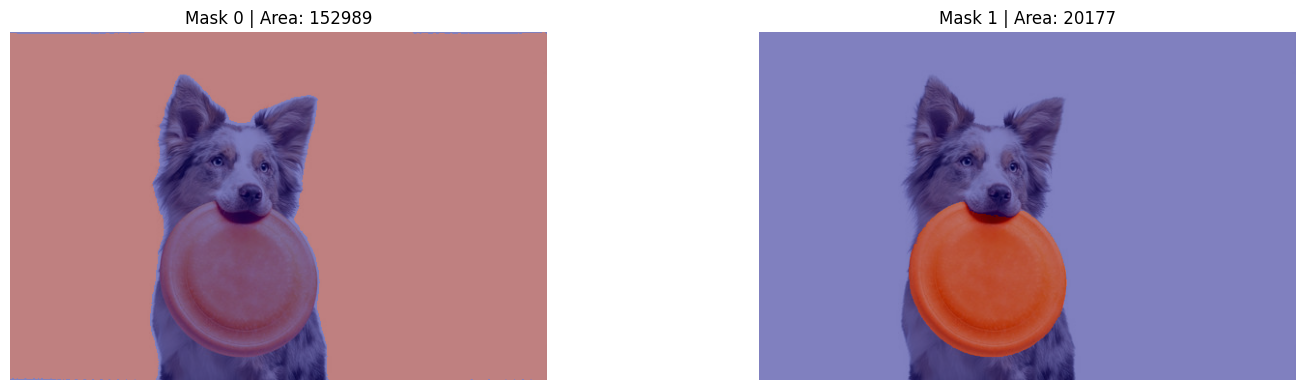

In [ ]:
# ── Xem masks ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(masks), figsize=(16, 4))
if len(masks) == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(img)
    ax.imshow(masks[i]["segmentation"], alpha=0.5, cmap="jet")
    ax.set_title(f"Mask {i} | Area: {masks[i]['area']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [ ]:
# ── Bước 2: Amodal Completion ──
from amodal_completer import AmodalCompleter

# ⚠️ Chọn mask_id muốn complete (xem hình ở trên)
MASK_ID = 0  # <-- thay số này

target_mask = masks[MASK_ID]["segmentation"].astype(bool)

completer = AmodalCompleter()
outputs = completer.complete(
    image=img,
    visible_mask=target_mask,
    all_masks=masks,
    max_iter=3,
)
print("✅ Amodal completion done!")

[AmodalShapePredictor] Loading Pix2Gestalt Checkpoint from ckpt/epoch=000005.ckpt...
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.54 M params.
Keeping EMAs of 688.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
[AmodalShapePredictor] Pix2Gestalt loaded successfully.
[VLMReasoner] Loading Official Qwen/Qwen3-VL-4B-Instruct (FP16)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

[VLMReasoner] Qwen/Qwen3-VL-4B-Instruct loaded successfully.
[AmodalCompleter] Loading Stable Diffusion inpainting model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[AmodalCompleter] Models loaded.
[AmodalCompleter] Step 0: Reasoning with Qwen3-VL...
[VLM Reason]: The target object is a dog holding an orange frisbee in its mouth. The missing parts are:

1. **The dog’s body**: The dog’s torso, legs, and tail are not visible in the image. The dog appears to be standing or sitting, but only its head and upper chest are shown.

2. **The frisbee’s edges**: The frisbee is partially obscured by the dog’s mouth, so the outer rim and edges of the frisbee are not
[AmodalCompleter] Step 1: Predicting amodal shape...
[AmodalShapePredictor] Synthesizing amodal object with Pix2Gestalt LDM...
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 199 timesteps


DDIM Sampler: 100%|██████████| 199/199 [00:09<00:00, 20.65it/s]
Token indices sequence length is longer than the specified maximum sequence length for this model (112 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['s edges **: the frisbee is partially obscured by the dog ’ s mouth , so the outer rim and edges of the frisbee are not , centered , high quality , consistent lighting']


[AmodalCompleter] Step 4: Synthesizing appearance...
✅ Amodal completion done!


In [ ]:
# Xóa thủ công cho đối tượng hiện tại của bạn
if hasattr(completer, '_shape_predictor'):
    del completer._shape_predictor
if hasattr(completer, '_pipe'):
    del completer._pipe
if hasattr(completer, '_vlm'):
    del completer._vlm

del completer
import gc; gc.collect()
import torch; torch.cuda.empty_cache()
print("GPU đã được giải phóng!")


GPU đã được giải phóng!


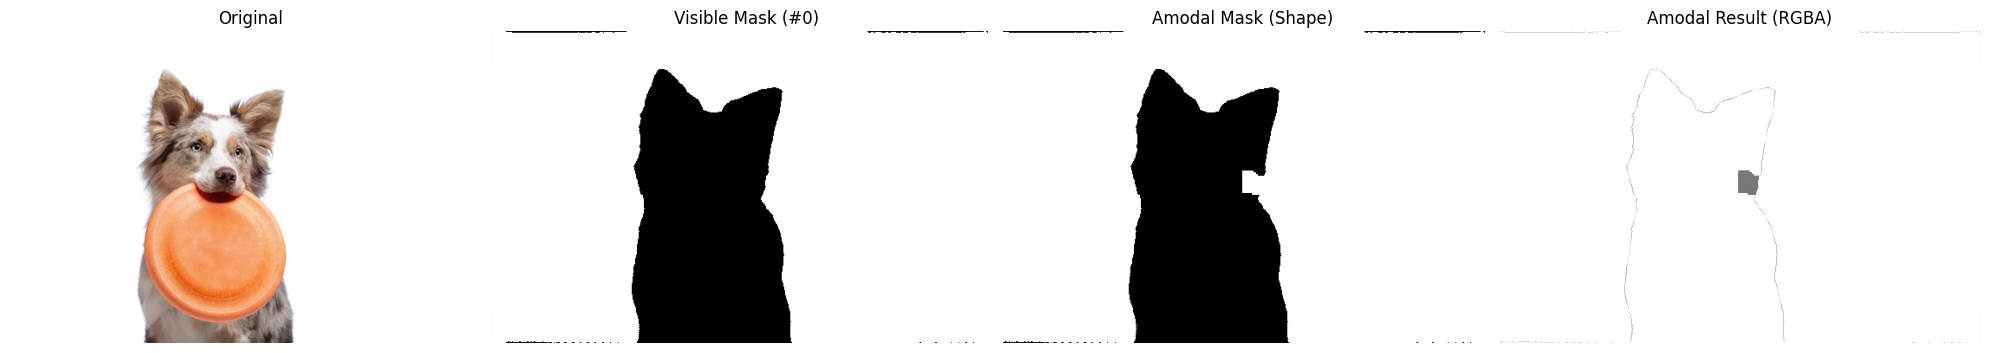

✅ Saved: amodal_result_mask0.png


/tmp/ipykernel_12071/1497207879.py:24: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  result_pil = Image.fromarray(rgba_result, mode="RGBA")


In [ ]:
# ── Xem kết quả ──
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(outputs["input_image"])
axes[0].set_title("Original")

axes[1].imshow(outputs["visible_mask"], cmap="gray")
axes[1].set_title(f"Visible Mask (#{MASK_ID})")

axes[2].imshow(outputs["amodal_mask"], cmap="gray")
axes[2].set_title("Amodal Mask (Shape)")

rgba_result = outputs["inpainted_rgba"]
axes[3].imshow(rgba_result)
axes[3].set_title("Amodal Result (RGBA)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Lưu kết quả
result_pil = Image.fromarray(rgba_result, mode="RGBA")
output_name = f"amodal_result_mask{MASK_ID}.png"
#result_pil.save(output_name)
print(f"✅ Saved: {output_name}")

# Download về máy
#files.download(output_name)

## EVALUATE COCOA

In [ ]:
!pip install -q datasets pycocotools

In [ ]:
!pip install -q lpips scikit-image datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.6 MB/s eta 0:00:00


In [ ]:
import os
import requests
import re
from tqdm import tqdm

list_file = "dataset/COCOA/img_filenames_cocoa.txt"
output_dir = "dataset/COCOA/images"
os.makedirs(output_dir, exist_ok=True)

with open(list_file, "r") as f:
    filenames = [line.strip() for line in f.readlines() if line.strip()]

print(f"Bắt đầu xử lý và tải {len(filenames)} ảnh (Hỗ trợ Train/Val/Test)...")

for raw_filename in tqdm(filenames):
    save_path = os.path.join(output_dir, raw_filename)
    if os.path.exists(save_path): continue

    # 1. Xử lý sạch tên file
    clean_name = raw_filename.replace("./", "")

    # 2. Tìm tên ảnh gốc COCO (Hỗ trợ thêm 'test')
    # Regex: COCO_ + (train hoặc val hoặc test) + 2014 + số ID
    match = re.search(r'(COCO_(train|val|test)2014_\d+)', clean_name)

    if not match:
        print(f"\n⚠️ Không nhận diện được định dạng COCO: {clean_name}")
        continue

    coco_id = match.group(1) + ".jpg"
    subset = match.group(2) + "2014" # Ví dụ: test2014

    # 3. Tạo URL chính xác từ server MS COCO
    url = f"http://images.cocodataset.org/{subset}/{coco_id}"

    try:
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            with open(save_path, "wb") as f:
                for chunk in response.iter_content(1024):
                    f.write(chunk)
        else:
            # Một số ảnh test có thể nằm trong tập dev-test hoặc server khác,
            # nhưng đa phần val/train/test2014 trên link này là chuẩn.
            print(f"\n❌ Thất bại: {url} (Status: {response.status_code})")
    except Exception as e:
        print(f"\n❌ Lỗi khi tải {raw_filename}: {e}")

print("\n✅ Hoàn thành tải toàn bộ ảnh!")


Bắt đầu xử lý và tải 845 ảnh (Hỗ trợ Train/Val/Test)...


100%|██████████| 845/845 [03:35<00:00,  3.92it/s]


✅ Hoàn thành tải toàn bộ ảnh!


In [ ]:
from evaluate_amodal import AmodalEvaluator

# Khởi tạo đối tượng đánh giá
# Quá trình này mất khoảng 2-3 phút và tốn ~35GB VRAM
evaluator = AmodalEvaluator(device="cuda")

print("✅ Tất cả Model đã sẵn sàng trên GPU!")


[AmodalShapePredictor] Loading Pix2Gestalt Checkpoint from ckpt/epoch=000005.ckpt...


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/distributed.py:258: LightningDeprecationWarning: `pytorch_lightning.utilities.distributed.rank_zero_only` has been deprecated in v1.8.1 and will be removed in v1.10.0. You can import it from `pytorch_lightning.utilities` instead.
  rank_zero_deprecation(


LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.54 M params.
Keeping EMAs of 688.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
[AmodalShapePredictor] Pix2Gestalt loaded successfully.
[VLMReasoner] Loading Official Qwen/Qwen3-VL-4B-Instruct (FP16)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

...

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-inpainting/snapshots/5f74973cbb64c8568780732c17f43eb269d63a0d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionInpaintPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


[AmodalCompleter] xformers not available, using attention slicing
[AmodalCompleter] Loading CLIP model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


[AmodalCompleter] Models loaded.
✅ Tất cả Model đã sẵn sàng trên GPU!


In [ ]:
from evaluate_amodal import AmodalEvaluator

# 1. Khởi tạo Evaluator (Nếu bạn vừa Restart session)
evaluator = AmodalEvaluator(device="cuda")

# 2. CHẠY ĐÁNH GIÁ VỚI FILE NÉN .GZ
# Hệ thống sẽ tự động giải nén và đọc dữ liệu chuẩn xác
evaluator.evaluate_cocoa(
    ann_file="dataset/COCOA/cocoa_annotation.json.gz",
    img_dir="dataset/COCOA/images",
    limit=100
)

# 3. Dọn dẹp GPU để xem kết quả
evaluator.cleanup()


[AmodalShapePredictor] Loading Pix2Gestalt Checkpoint from ckpt/epoch=000005.ckpt...
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.54 M params.
Keeping EMAs of 688.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
[AmodalShapePredictor] Pix2Gestalt loaded successfully.
[VLMReasoner] Loading Official Qwen/Qwen3-VL-4B-Instruct (FP16)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

[VLMReasoner] Qwen/Qwen3-VL-4B-Instruct loaded successfully.
[AmodalCompleter] Loading Stable Diffusion inpainting model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

...


DDIM Sampler: 100%|██████████| 199/199 [00:10<00:00, 19.88it/s]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['cover the rear wheel and help shield the rider from dirt and water . additionally , the handlebars , which are essential for steering , centered , high quality , consistent lighting']


[AmodalCompleter] Step 4: Synthesizing appearance...


100%|██████████| 100/100 [27:40<00:00, 16.61s/it]


[Evaluator] Results saved to cocoa_subset_results.csv
Mean mIoU: 0.0000
Mean oIoU: 0.0000


AttributeError: 'AmodalCompleter' object has no attribute 'cleanup'

In [ ]:
import pandas as pd
df = pd.read_csv("cocoa_subset_results.csv")
print("--- KẾT QUẢ ĐÁNH GIÁ TRUNG BÌNH ---")
print(df[['mIoU', 'oIoU', 'LPIPS', 'SSIM']].mean())


--- KẾT QUẢ ĐÁNH GIÁ TRUNG BÌNH ---
mIoU     0.000000
oIoU     0.000000
LPIPS    0.112036
SSIM     0.892584
dtype: float64


In [ ]:
from google.colab import files
files.download('cocoa_subset_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>